# Standard DSPOT and its modifications

In [1]:
# Load the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

from evt_checks import plot_evt_diagnostics
from spot_copy import SPOT, dSPOT, ModifiedSPOT, moving_average, OnlinePreprocessor
from eqd import eqd

from scipy.stats import median_abs_deviation
from statsmodels.tsa.seasonal import STL
from datetime import datetime
from statsmodels.graphics.tsaplots import plot_acf
from collections import deque
from itertools import product

# Load the data
df2 = pd.read_csv("../../data/raw_data/Twitter_volume_AMZN.csv", parse_dates=[0], index_col=0)
df2.columns = ["value"]
series_raw = df2['value']

# Load the labels (window-based)
with open("../../data/raw_data/combined_windows.json") as f:
    all_windows = json.load(f)

dataset_key = "realTweets/Twitter_volume_AMZN.csv" # set the key 
window_strs = all_windows.get(dataset_key, []) # get the list of window strings

# Convert to datetime tuples
anomaly_windows = [
    (datetime.strptime(start, "%Y-%m-%d %H:%M:%S.%f"),
     datetime.strptime(end, "%Y-%m-%d %H:%M:%S.%f"))
    for start, end in window_strs
]

### Vanilla DSPOT

Now, we use the provided real anomalies to evaluate the performance of the DSPOT on the realTraffic data. Since the real anomalies are defined as windows, we introduce the event-based anomaly detection. 

In [2]:
# Reload data, preload timestamps & anomaly windows
df2 = pd.read_csv("../../data/raw_data/Twitter_volume_AMZN.csv", parse_dates=[0])
df2.columns = ["timestamp", "value"]
timestamps  = pd.to_datetime(df2.iloc[:, 0])

def align_windows_to_series(windows, ts_series):
    """
    Convert a list of (start,end) datetimes to pandas Timestamps that match the
    timezone-awareness of ts_series (Series or DatetimeIndex).
    """
    idx = pd.to_datetime(ts_series)
    # Get tz info depending on type
    if isinstance(idx, pd.Series):
        tz = idx.dt.tz
    elif isinstance(idx, pd.DatetimeIndex):
        tz = idx.tz
    else:
        tz = None

    aligned = []
    for s, e in windows:
        s_ts = pd.Timestamp(s)
        e_ts = pd.Timestamp(e)
        if e_ts < s_ts:
            s_ts, e_ts = e_ts, s_ts

        if tz is None:
            # force naive
            s_ts = s_ts.tz_localize(None) if s_ts.tzinfo else s_ts
            e_ts = e_ts.tz_localize(None) if e_ts.tzinfo else e_ts
        else:
            # ensure aware and convert
            s_ts = (s_ts.tz_localize("UTC") if s_ts.tzinfo is None else s_ts).tz_convert(tz)
            e_ts = (e_ts.tz_localize("UTC") if e_ts.tzinfo is None else e_ts).tz_convert(tz)

        aligned.append((s_ts, e_ts))
    return aligned

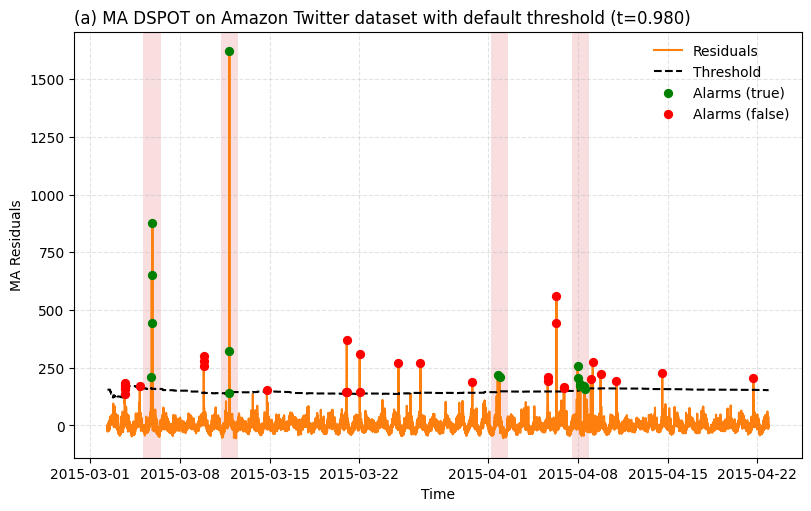

In [23]:
# Prep the time index to match the full series length
full_index = series_raw.index 

# Build ground-truth anomaly windows aligned to this index
with open("../../data/raw_data/combined_windows.json") as f:
    all_windows = json.load(f)
dataset_key = "realTweets/Twitter_volume_AMZN.csv"

from datetime import datetime
window_strs = all_windows.get(dataset_key, [])
raw_windows = [
    (datetime.strptime(start, "%Y-%m-%d %H:%M:%S.%f"),
     datetime.strptime(end,   "%Y-%m-%d %H:%M:%S.%f"))
    for start, end in window_strs
]

def merge_overlapping(intervals):
    if not intervals:
        return []
    intervals = sorted(intervals, key=lambda x: x[0])
    merged = [list(intervals[0])]
    for s, e in intervals[1:]:
        if s <= merged[-1][1]:
            merged[-1][1] = max(merged[-1][1], e)
        else:
            merged.append([s, e])
    return [(s, e) for s, e in merged]

anomaly_windows_dt = merge_overlapping(align_windows_to_series(raw_windows, full_index))
anomaly_windows_dt = [(max(s, full_index.min()), min(e, full_index.max()))
                      for s, e in anomaly_windows_dt if max(s, full_index.min()) <= min(e, full_index.max())]

# Set parameters
init_data = 1000                             
proba     = 1e-4 
depth     = 288 
init_batch = series_raw[:init_data].values

# Run dSPOT
model = dSPOT(q=proba, depth=depth)
model.fit(init_data=init_batch, data=series_raw[init_data:].values)
model.initialize()
results = model.run(with_alarm=True)
fig, ax = model.plot(
    results,
    with_alarm=True,
    figsize=(8, 5),
    title="(a) MA DSPOT on Amazon Twitter dataset with default threshold (t=0.980)",
    label="MA Residuals",
    data_color="tab:orange",                # (1) your data colour
    threshold_color="black",             # (3) threshold forced to black
    true_alarm_color="green",            # (3) alarms inside windows -> green
    false_alarm_color="red",
    shade_color="tab:red", shade_alpha=0.15,  # (2) light-red shading
    ts_index=full_index,                 # datetime x-axis
    anomaly_windows=anomaly_windows_dt                          # let us save first
)
fig.savefig("../../output/realTweets/original_dspot_realTweets.png", dpi=300)
plt.show()

In [24]:
## Event-based Evaluation
# Parameters + mapping 
offsets  = np.array(results["alarms"], dtype=int)
detected = timestamps.iloc[init_data + offsets].sort_values().to_list()

# Collapse consecutive alarms into alarm events
min_gap = pd.Timedelta("5min")
alarm_events = []
if detected:
    ev_start = detected[0]
    ev_end   = detected[0]
    for t in detected[1:]:
        if t - ev_end > min_gap:  
            alarm_events.append((ev_start, ev_end))
            ev_start = t
        ev_end = t
    alarm_events.append((ev_start, ev_end))

# Sort ground-truth windows + introduce "earliest unmatched" rule
gt_windows = sorted(list(anomaly_windows), key=lambda w: w[0])  # ensure sorted
TP, FP = 0, 0
delays = []
matched_gt = set()

for (a_start, a_end) in alarm_events:
    # find indices of ground-truth windows
    overlaps = [i for i, (g_start, g_end) in enumerate(gt_windows)
                if not (a_end < g_start or a_start > g_end)]
    if overlaps:
        # assign to earliest unmatched overlapping GT window, if any
        assigned = False
        for i in overlaps:
            if i not in matched_gt:
                matched_gt.add(i)
                TP += 1
                g_start = gt_windows[i][0]
                # define delay 
                delay_min = max(0.0, (a_start - g_start).total_seconds() / 60.0)
                delays.append(delay_min)
                assigned = True
                break
        if not assigned:
            pass
    else:
        FP += 1

FN = len(gt_windows) - TP

# Compute metrics
precision = TP / (TP + FP) if (TP + FP) > 0 else float("nan")
recall    = TP / (TP + FN) if (TP + FN) > 0 else float("nan")
f1        = (2 * precision * recall / (precision + recall)
             if np.isfinite(precision) and np.isfinite(recall) and (precision + recall) > 0
             else float("nan"))
mean_delay   = np.nanmean(delays)  if delays else float("nan")
median_delay = np.nanmedian(delays) if delays else float("nan")

print(f"TP={TP}, FP={FP}, FN={FN}")
print(f"Precision={precision:.3f}  Recall={recall:.3f}  F1={f1:.3f}")
print(f"Median delay = {median_delay:.1f} min")


TP=4, FP=20, FN=0
Precision=0.167  Recall=1.000  F1=0.286
Median delay = 837.5 min


TP=4, FP=26, FN=0
Precision=0.133, Recall=1.000, F1=0.235
Mean delay = 836.2 min, Median delay = 837.5 min

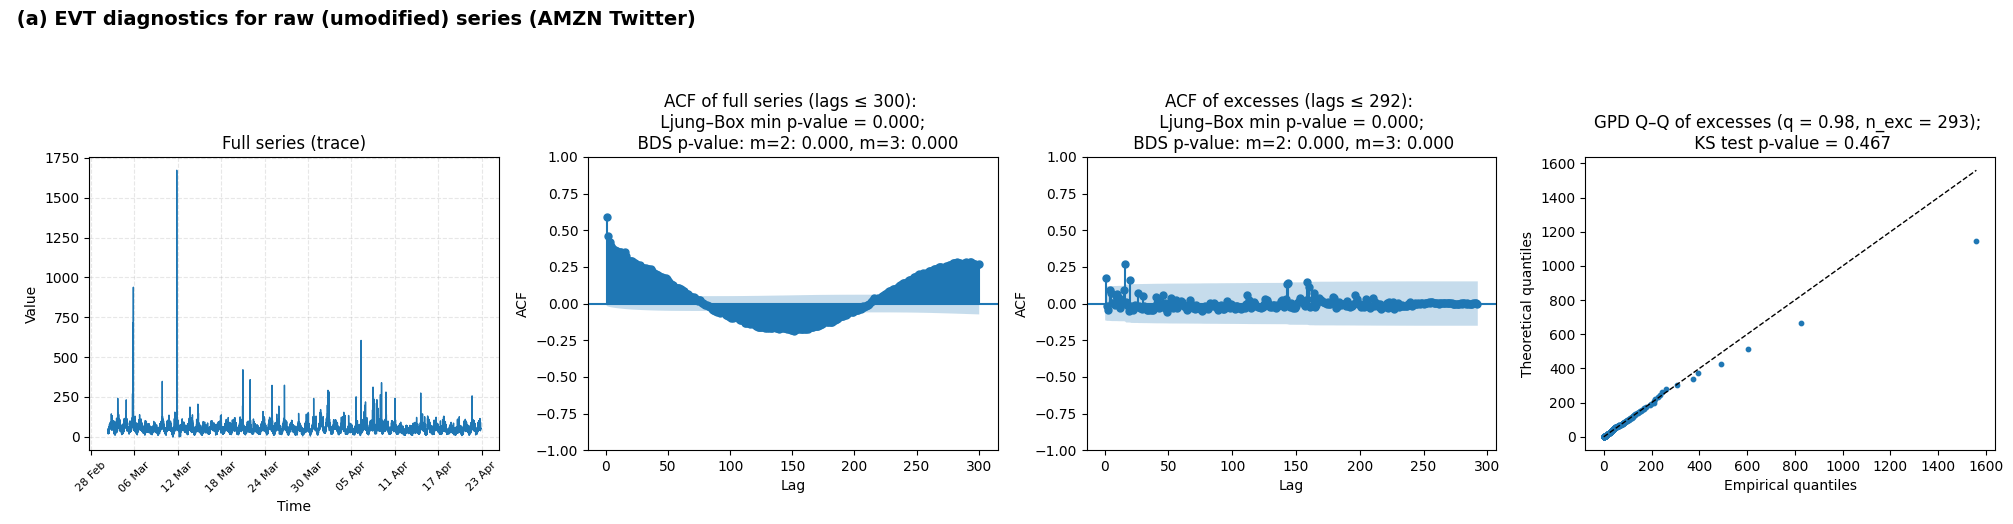

In [5]:
# print evt diagnostic for the raw time series
df2 = pd.read_csv("../../data/raw_data/Twitter_volume_AMZN.csv",
                  parse_dates=[0], header=0)
df2.columns = ["timestamp", "value"]
s_raw = df2.set_index("timestamp")["value"].astype(float)
s_raw = s_raw.iloc[1000:]

fig = plot_evt_diagnostics(s_raw, exceed_q=0.98, acf_lags=300, bds_max_dim=3, 
                           title=" (a) EVT diagnostics for raw (umodified) series (AMZN Twitter)")
plt.show(fig)
fig.savefig("../../output/realTweets/evt_raw_diagnostics_realTweets.png", dpi=300, bbox_inches='tight')

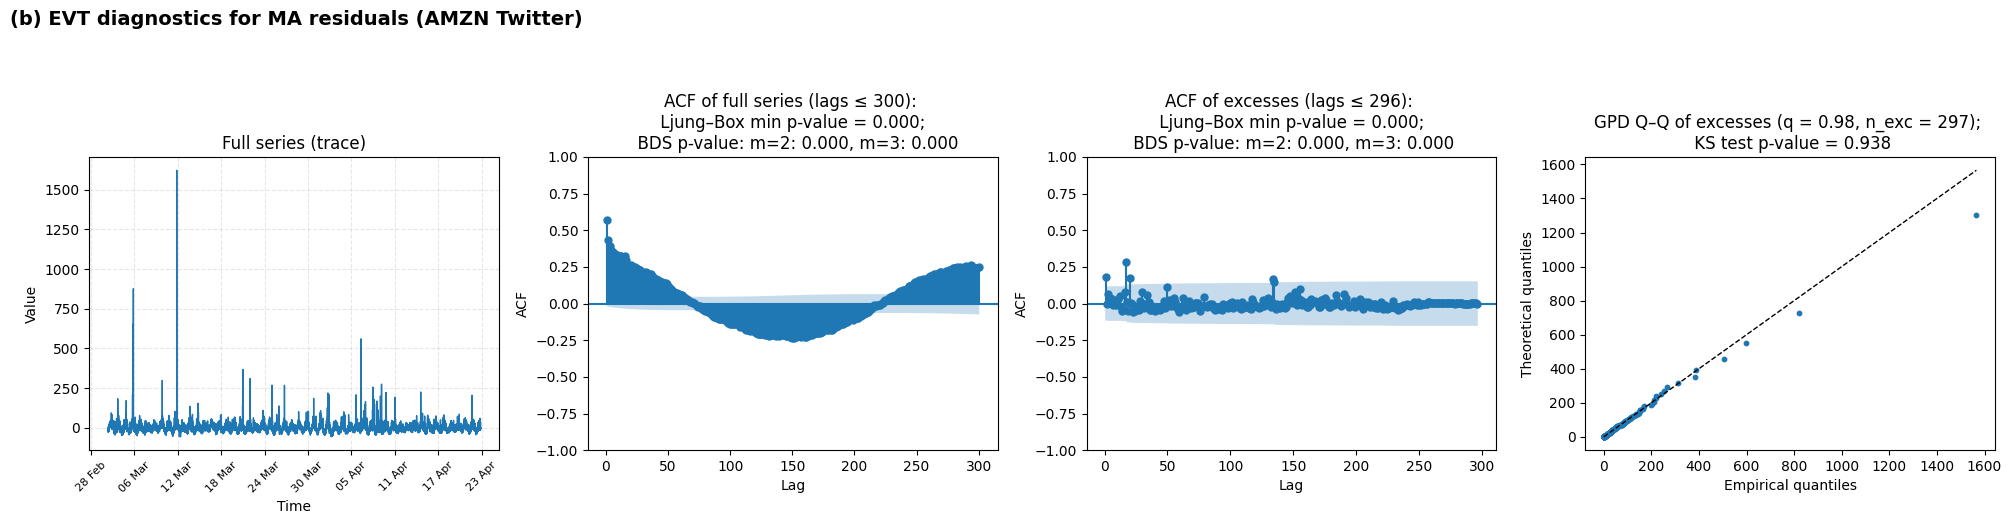

In [6]:
# print evt diagnostic for the residuals used in vanilla dSPOT
residuals  = np.array(results["residuals"])
raw_index = series_raw.index
resid_series = pd.Series(residuals, index=raw_index)
clean_resid = resid_series.dropna()

fig = plot_evt_diagnostics(clean_resid, exceed_q=0.98, acf_lags=300, bds_max_dim=3, 
                           title="(b) EVT diagnostics for MA residuals (AMZN Twitter)")
plt.show(fig)
fig.savefig("../../output/realTweets/evt_ma_diagnostics_realTweets.png", dpi=300, bbox_inches='tight')

Next, we use rigourosly chosen first cutoff threshold on the Vanilla DSPOT to see wether it will improve the fit

In [38]:
# Set paramaters
init_data = 1000
depth = 288
init_batch = series_raw[:init_data].values

# Compute MA residuals using dSPOT logic
residuals = init_batch[depth:] - moving_average(init_batch, depth)[:-1]

# Run EQD on MA residuals
thresholds = np.quantile(residuals, np.linspace(0.901, 0.999, 30))
np.random.seed(27)
result = eqd(residuals, thresholds)
u_gpd = result["threshold"]
param = result["params"]

print("Selected threshold:", u_gpd)
print("GPD parameters:", param)
print("Estimated as quantile level: ", np.mean(residuals <= result["threshold"]))
residuals = init_batch[depth:] - moving_average(init_batch, depth)[:-1]
print("Num peaks:", np.sum(residuals > u_gpd))
print("Max peak value:", residuals[residuals > u_gpd].max())
print("Mean peak value:", residuals[residuals > u_gpd].mean())

# Compute level
level = np.mean(residuals <= u_gpd)
print(level)

Selected threshold: 17.978006944444445
GPD parameters: (8.921775820317405, 0.27885902503984084)
Estimated as quantile level:  0.9002808988764045
Num peaks: 71
Max peak value: 198.26388888888889
Mean peak value: 30.754499217527385
0.9002808988764045


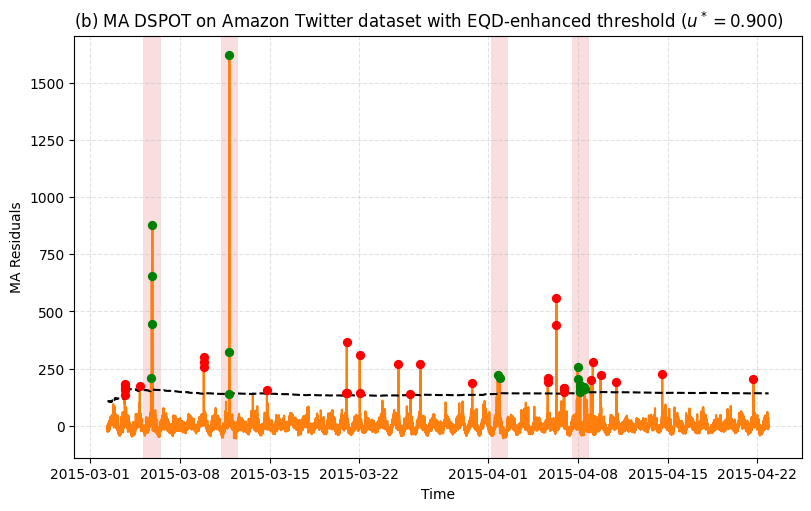

In [39]:
# 3) Use the selected threshold for SPOT 
model = dSPOT(q=1e-4, depth = 288)
model.fit(init_data=init_batch, data=series_raw[init_data:].values)
model.initialize(level=level)
results = model.run()
fig, ax = model.plot(results,
    with_alarm=True,
    figsize=(8, 5),
    title=fr"(b) MA DSPOT on Amazon Twitter dataset with EQD-enhanced threshold ($u^* = 0.900$)",
    show_legend=False,                 
    label="MA Residuals",
    data_color="tab:orange",           
    threshold_color="black", 
    true_alarm_color="green", 
    false_alarm_color="red",
    shade_color="tab:red", shade_alpha=0.15, 
    ts_index=full_index,                
    anomaly_windows=anomaly_windows_dt        
)
fig.savefig("../../output/realTweets/optimal_threshold_dspot_realTweets.png", dpi=300)   # Save before showing
plt.show()

In [40]:
## Event-based Evaluation as before 
# Parameters + mapping 
offsets  = np.array(results["alarms"], dtype=int)
detected = timestamps.iloc[init_data + offsets].sort_values().to_list()

# Collapse consecutive alarms into alarm events
min_gap = pd.Timedelta("5min")
alarm_events = []
if detected:
    ev_start = detected[0]
    ev_end   = detected[0]
    for t in detected[1:]:
        if t - ev_end > min_gap:  
            alarm_events.append((ev_start, ev_end))
            ev_start = t
        ev_end = t
    alarm_events.append((ev_start, ev_end))

# Sort ground-truth windows + introduce "earliest unmatched" rule
gt_windows = sorted(list(anomaly_windows), key=lambda w: w[0])  # ensure sorted
TP, FP = 0, 0
delays = []
matched_gt = set()

for (a_start, a_end) in alarm_events:
    # find indices of ground-truth windows
    overlaps = [i for i, (g_start, g_end) in enumerate(gt_windows)
                if not (a_end < g_start or a_start > g_end)]
    if overlaps:
        # assign to earliest unmatched overlapping GT window, if any
        assigned = False
        for i in overlaps:
            if i not in matched_gt:
                matched_gt.add(i)
                TP += 1
                g_start = gt_windows[i][0]
                # define delay 
                delay_min = max(0.0, (a_start - g_start).total_seconds() / 60.0)
                delays.append(delay_min)
                assigned = True
                break
        if not assigned:
            pass
    else:
        FP += 1

FN = len(gt_windows) - TP

# Compute metrics
precision = TP / (TP + FP) if (TP + FP) > 0 else float("nan")
recall    = TP / (TP + FN) if (TP + FN) > 0 else float("nan")
f1        = (2 * precision * recall / (precision + recall)
             if np.isfinite(precision) and np.isfinite(recall) and (precision + recall) > 0
             else float("nan"))
mean_delay   = np.nanmean(delays)  if delays else float("nan")
median_delay = np.nanmedian(delays) if delays else float("nan")

print(f"TP={TP}, FP={FP}, FN={FN}")
print(f"Precision={precision:.3f}  Recall={recall:.3f}  F1={f1:.3f}")
print(f"Median delay = {median_delay:.1f} min")

TP=4, FP=22, FN=0
Precision=0.154  Recall=1.000  F1=0.267
Median delay = 837.5 min


TP=4, FP=30, FN=0
Precision=0.118, Recall=1.000, F1=0.211
Mean delay = 836.2 min, Median delay = 837.5 min

### DSPOT Extensions for Stationary Residuals

EWMA + seasonal differencing + variance normalisation on SPOT

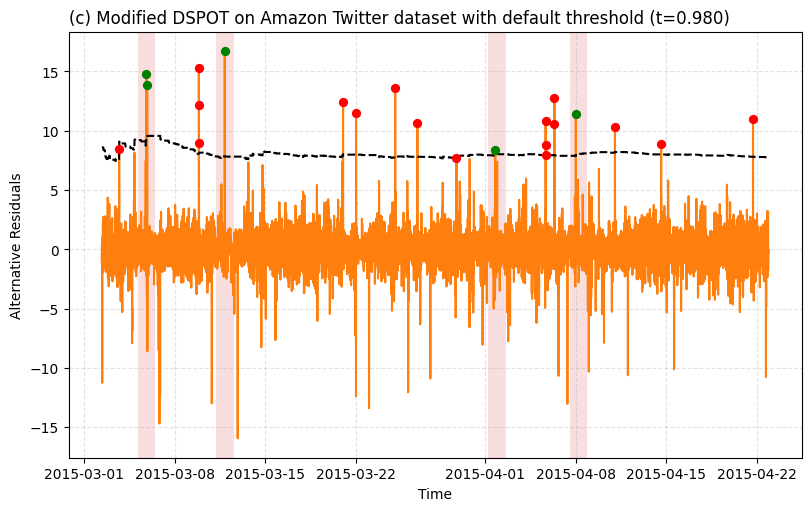

In [28]:
# Load data
df2 = pd.read_csv("../../data/raw_data/Twitter_volume_AMZN.csv", parse_dates=[0])
df2.columns = ["timestamp", "value"]
timestamps = pd.to_datetime(df2["timestamp"])
series = df2["value"]

# Parameters
init_data = 1000
q = 1e-4

# Split initial calibration and stream
init_series = series[:init_data]
stream_series = series[init_data:]
ts_stream = timestamps.iloc[init_data:]

# Run ModifiedSPOT
model = ModifiedSPOT(q=q, seasonal_period=288, ewma_alpha=0.05)
model.fit(init_data=init_series, data=stream_series)
model.initialize()
results = model.run()
fig, ax = model.plot(results,
    with_alarm=True,
    figsize=(8, 5),
    title="(c) Modified DSPOT on Amazon Twitter dataset with default threshold (t=0.980)",
    show_legend=False,
    label="Alternative Residuals",
    data_color="tab:orange",           
    threshold_color="black", 
    true_alarm_color="green", 
    false_alarm_color="red",
    shade_color="tab:red", shade_alpha=0.15, 
    ts_index=full_index,                
    anomaly_windows=anomaly_windows_dt        
)
fig.savefig("../../output/realTweets/preprocessed_spot_realTweets.png", dpi=300)   # Save before showing
plt.show()

In [29]:
## Event-based Evaluation
# Parameters + mapping 
offsets  = np.array(results["alarms"], dtype=int)
detected = timestamps.iloc[init_data + offsets].sort_values().to_list()

# Collapse consecutive alarms into alarm events
min_gap = pd.Timedelta("5min")
alarm_events = []
if detected:
    ev_start = detected[0]
    ev_end   = detected[0]
    for t in detected[1:]:
        if t - ev_end > min_gap:  
            alarm_events.append((ev_start, ev_end))
            ev_start = t
        ev_end = t
    alarm_events.append((ev_start, ev_end))

# Sort ground-truth windows + introduce "earliest unmatched" rule
gt_windows = sorted(list(anomaly_windows), key=lambda w: w[0])  # ensure sorted
TP, FP = 0, 0
delays = []
matched_gt = set()

for (a_start, a_end) in alarm_events:
    # find indices of ground-truth windows
    overlaps = [i for i, (g_start, g_end) in enumerate(gt_windows)
                if not (a_end < g_start or a_start > g_end)]
    if overlaps:
        # assign to earliest unmatched overlapping GT window, if any
        assigned = False
        for i in overlaps:
            if i not in matched_gt:
                matched_gt.add(i)
                TP += 1
                g_start = gt_windows[i][0]
                # define delay 
                delay_min = max(0.0, (a_start - g_start).total_seconds() / 60.0)
                delays.append(delay_min)
                assigned = True
                break
        if not assigned:
            pass
    else:
        FP += 1

FN = len(gt_windows) - TP

# Compute metrics
precision = TP / (TP + FP) if (TP + FP) > 0 else float("nan")
recall    = TP / (TP + FN) if (TP + FN) > 0 else float("nan")
f1        = (2 * precision * recall / (precision + recall)
             if np.isfinite(precision) and np.isfinite(recall) and (precision + recall) > 0
             else float("nan"))
mean_delay   = np.nanmean(delays)  if delays else float("nan")
median_delay = np.nanmedian(delays) if delays else float("nan")

print(f"TP={TP}, FP={FP}, FN={FN}")
print(f"Precision={precision:.3f}  Recall={recall:.3f}  F1={f1:.3f}")
print(f"Median delay = {median_delay:.1f} min")

TP=4, FP=12, FN=0
Precision=0.250  Recall=1.000  F1=0.400
Median delay = 880.0 min


TP=4, FP=13, FN=0
Precision=0.235, Recall=1.000, F1=0.381
Mean delay = 857.5 min, Median delay = 880.0 min

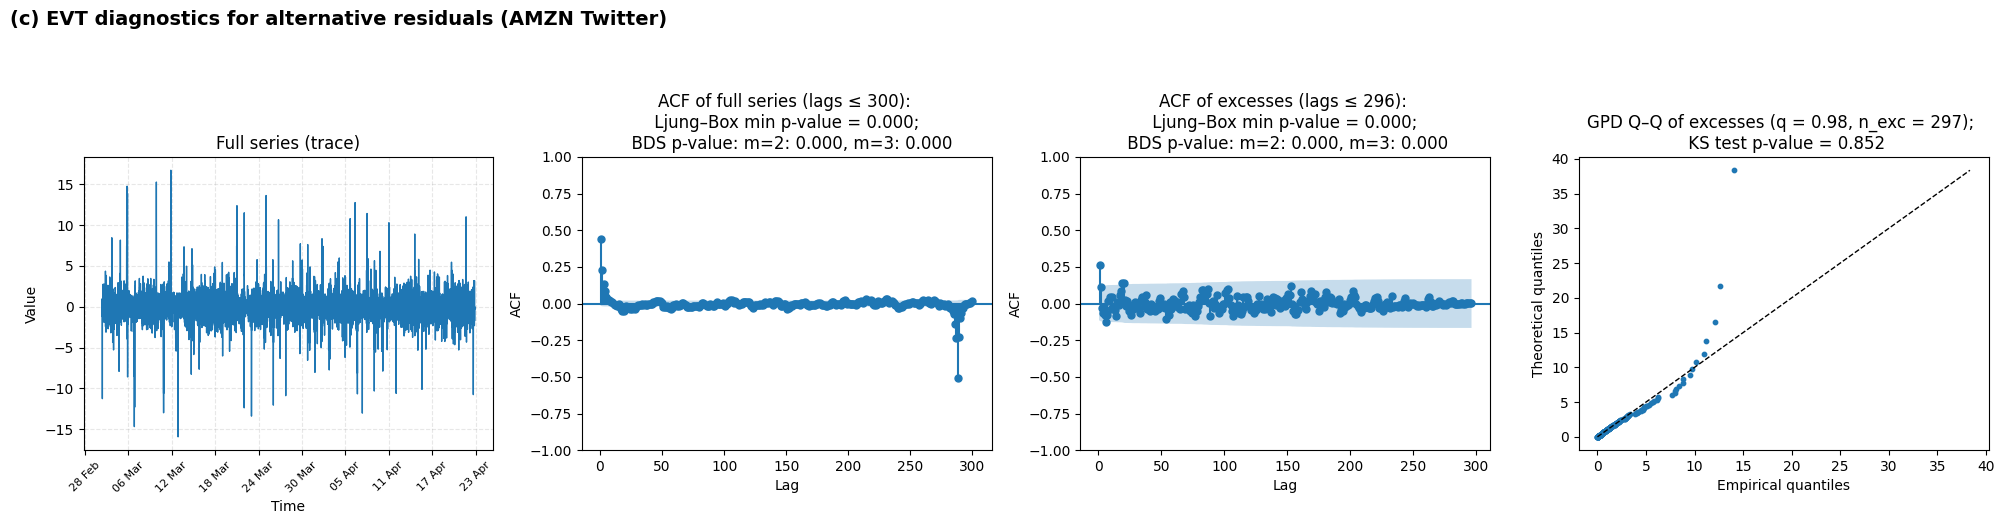

In [12]:
# print evt diagnostic for the residuals used in vanilla dSPOT
residuals  = np.array(results["residuals"])
raw_index = series_raw.index
resid_series = pd.Series(residuals, index=raw_index)
clean_resid = resid_series.dropna()

fig = plot_evt_diagnostics(clean_resid, exceed_q=0.98, acf_lags=300, bds_max_dim=3, 
                           title="(c) EVT diagnostics for alternative residuals (AMZN Twitter)")
plt.show(fig)
fig.savefig("../../output/realTweets/evt_prep_diagnostics_realTweets.png", dpi=300, bbox_inches='tight')

Now, let's enhance our method with optimal chosen initial threshold

In [41]:
# Parameters
init_data = 1000
q = 1e-3

# Load your data
df_clean = pd.read_csv("../../data/raw_data/Twitter_volume_AMZN.csv", parse_dates=[0])
df_clean.columns = ["timestamp", "value"]
timestamps = df_clean["timestamp"]
series = df_clean["value"].values

# Split initial calibration and stream
init_series = series[:init_data]
stream_series = series[init_data:]
ts_stream = timestamps.iloc[init_data:]

# 1. Preprocess init_series with the same logic as in ModifiedSPOT
preproc = OnlinePreprocessor(P=288, alpha=0.05)
residuals = []
for x in init_series:
    z = preproc.update(x)
    if z is not None:
        residuals.append(z)
residuals = np.array(residuals)

# Run EQD on preprocesed residuals
np.random.seed(27)
thresholds = np.quantile(residuals, np.linspace(0.90, 0.99, 30))
eqd_result = eqd(residuals, thresholds)
u_gpd = eqd_result["threshold"]
param = eqd_result["params"]

print("Selected threshold: ", u_gpd)
print("GPD parameters: ", param)
print("Estimated as quantile level: ", np.mean(residuals <= eqd_result["threshold"]))
print("Num peaks:", np.sum(residuals > u_gpd))
print("Max peak value:", residuals[residuals > u_gpd].max())
print("Mean peak value:", residuals[residuals > u_gpd].mean())

Selected threshold:  1.4491673172942903
GPD parameters:  (0.45533604908845665, 0.33067460090506806)
Estimated as quantile level:  0.9058988764044944
Num peaks: 67
Max peak value: 10.321819492477053
Mean peak value: 2.1406919198099676


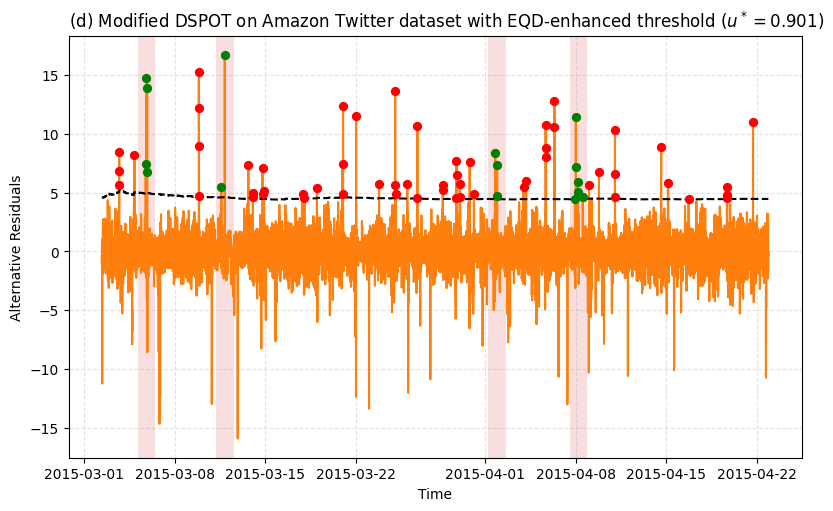

In [42]:
# Compute level
level = np.mean(residuals <= u_gpd)

# Run ModifiedSPOT
model = ModifiedSPOT(q=q, seasonal_period=288, ewma_alpha=0.05)
model.fit(init_data=init_series, data=stream_series)
model.initialize(level=level)
results = model.run()
fig, ax = model.plot(results,
    with_alarm=True,
    figsize=(8, 5),
    title=fr"(d) Modified DSPOT on Amazon Twitter dataset with EQD-enhanced threshold ($u^* = 0.901$)",
    show_legend=False,
    label="Alternative Residuals",
    data_color="tab:orange",           
    threshold_color="black", 
    true_alarm_color="green", 
    false_alarm_color="red",
    shade_color="tab:red", shade_alpha=0.15, 
    ts_index=full_index,                
    anomaly_windows=anomaly_windows_dt        
)
fig.savefig("../../output/realTweets/optimal_threshold_preprocessed_spot_realTweets.png", dpi=300, bbox_inches="tight") 
plt.show()

In [44]:
## Event-based Evaluation as before
# Parameters + mapping 
offsets  = np.array(results["alarms"], dtype=int)
detected = timestamps.iloc[init_data + offsets].sort_values().to_list()

# Collapse consecutive alarms into alarm events
min_gap = pd.Timedelta("5min")
alarm_events = []
if detected:
    ev_start = detected[0]
    ev_end   = detected[0]
    for t in detected[1:]:
        if t - ev_end > min_gap:  
            alarm_events.append((ev_start, ev_end))
            ev_start = t
        ev_end = t
    alarm_events.append((ev_start, ev_end))

# Sort ground-truth windows + introduce "earliest unmatched" rule
gt_windows = sorted(list(anomaly_windows), key=lambda w: w[0])  # ensure sorted
TP, FP = 0, 0
delays = []
matched_gt = set()

for (a_start, a_end) in alarm_events:
    # find indices of ground-truth windows
    overlaps = [i for i, (g_start, g_end) in enumerate(gt_windows)
                if not (a_end < g_start or a_start > g_end)]
    if overlaps:
        # assign to earliest unmatched overlapping GT window, if any
        assigned = False
        for i in overlaps:
            if i not in matched_gt:
                matched_gt.add(i)
                TP += 1
                g_start = gt_windows[i][0]
                # define delay 
                delay_min = max(0.0, (a_start - g_start).total_seconds() / 60.0)
                delays.append(delay_min)
                assigned = True
                break
        if not assigned:
            pass
    else:
        FP += 1

FN = len(gt_windows) - TP

# Compute metrics
precision = TP / (TP + FP) if (TP + FP) > 0 else float("nan")
recall    = TP / (TP + FN) if (TP + FN) > 0 else float("nan")
f1        = (2 * precision * recall / (precision + recall)
             if np.isfinite(precision) and np.isfinite(recall) and (precision + recall) > 0
             else float("nan"))
mean_delay   = np.nanmean(delays)  if delays else float("nan")
median_delay = np.nanmedian(delays) if delays else float("nan")

print(f"TP={TP}, FP={FP}, FN={FN}")
print(f"Precision={precision:.3f}  Recall={recall:.3f}  F1={f1:.3f}")
print(f"Median delay = {median_delay:.1f} min")

TP=4, FP=38, FN=0
Precision=0.095  Recall=1.000  F1=0.174
Median delay = 690.0 min


P=4, FP=46, FN=0
Precision=0.080, Recall=1.000, F1=0.148
Mean delay = 717.5 min, Median delay = 690.0 min

### Compute Wilson CI for each DSPOT variant

In [13]:
from math import sqrt

def wilson_ci(tp, fp_or_fn, z=1.96, kind="precision"):
    if kind == "precision":
        x, n = tp, tp + fp_or_fn
    else:  # recall
        x, n = tp, tp + fp_or_fn
    if n == 0:
        return float('nan'), float('nan'), float('nan')  # NA
    phat = x / n
    denom = 1 + z*z/n
    center = (phat + z*z/(2*n)) / denom
    radius = (z * sqrt(phat*(1-phat)/n + z*z/(4*n*n))) / denom
    return phat, center - radius, center + radius

def format_metric(tp, fp, fn, f1):
    p, p_lo, p_hi = wilson_ci(tp, fp, kind="precision")
    r, r_lo, r_hi = wilson_ci(tp, fn, kind="recall")
    return (f"{p:.3f} [{p_lo:.3f}, {p_hi:.3f}]",
            f"{r:.3f} [{r_lo:.3f}, {r_hi:.3f}]",
            f"{f1:.3f}")


In [33]:
# Original DSPOT
format_metric(4, 20, 0, 0.286) #TP,FP,FN,F1


('0.167 [0.067, 0.359]', '1.000 [0.510, 1.000]', '0.286')

In [34]:
# Original DSPOT + EQD
format_metric(4, 22, 0, 0.267)

('0.154 [0.061, 0.335]', '1.000 [0.510, 1.000]', '0.267')

In [35]:
# Modified DSPOT
format_metric(4, 11, 0, 0.4)

('0.267 [0.109, 0.520]', '1.000 [0.510, 1.000]', '0.400')

In [36]:
# Modified DSPOT + EQD
format_metric(4, 38, 0, 0.174)

('0.095 [0.038, 0.221]', '1.000 [0.510, 1.000]', '0.174')